# Unsupervised Machine Learning Workshop

In this workshop you will practice **unsupervised learning** — discovering structure in data without predefined labels. You will work in groups, with each member running a different clustering algorithm as a parallel experiment on its own Git branch. At the end, you will compare results through Pull Requests.

### Why unsupervised learning?

When you don't have labeled data, unsupervised algorithms can find **natural groupings**, reduce dimensionality, and detect anomalies. The challenge: *how do you know if the algorithm learned something useful?* That is what this workshop is about.

### Choose your dataset

**Option A (recommended):** Use a dataset related to your own project. Any tabular CSV with at least 2-3 numerical columns will work.

**Option B:** Use one of these classic clustering datasets:

| Dataset | Rows | Features | Why it works well | Link |
|---------|------|----------|-------------------|------|
| Mall Customers | 200 | 5 (Age, Income, Spending Score) | Different scales, clear segments | [Kaggle](https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python) |
| Wholesale Customers | 440 | 8 (spending across product categories) | Multi-dimensional, real purchasing data | [UCI ML Repository](https://archive.ics.uci.edu/dataset/292/wholesale+customers) |
| Penguins | 344 | 4 numeric + species label (ignore for clustering, use to validate) | Clean, small, good for beginners | `sns.load_dataset('penguins')` — built into seaborn |

### How this workshop works

- Exercises are marked with difficulty: \*  (basic), \*\* (intermediate), \*\*\* (challenge)
- Everyone should complete the \* exercises
- **Parts 0 and 1 are done together as a group** on the `main` branch
- **Part 2 is done individually** — each group member picks one algorithm and works on a separate branch
- **Parts 3-4** bring the group back together to compare and synthesize

---

---
## Part 0: Repository & Group Setup (~10 min)

You will practice a collaborative GitHub workflow: **one fork per group**, separate branches for each experiment, Pull Requests to compare and merge.

### Step 1 — One person forks the repository

One group member forks the workshop repository on GitHub and **adds the other members as collaborators** (Settings → Collaborators).

### Step 2 — Everyone clones the same fork

```bash
git clone https://github.com/<FORK-OWNER>/Workshop-UML.git
cd Workshop-UML
```

### Step 3 — Stay on `main` for now

Parts 0 and 1 are shared work. You will create individual branches in Part 2.

---

## Setup

Run this cell to import libraries. If any are missing, install with `pip install <package>`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage

# Nicer defaults
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 20)

print("All imports OK")

All imports OK


---
## Part 1: Data Preparation & Scaling (~20 min)

**Do this together as a group on `main`.** Everyone should have the same clean, scaled dataset before branching out.

Clustering algorithms are sensitive to the **scale** of features. If one column ranges from 0-100 and another from 0-100,000, the large-range column will dominate distance calculations, and the algorithm will essentially ignore the small-range column.

### Exercise 1.1 * — Load and inspect

Load your dataset and get oriented:
- How many rows and columns?
- Which columns are numerical? Which are categorical?
- Are there missing values? (Handle them now — clustering algorithms typically can't handle NaN.)

Useful: `pd.read_csv()`, `.info()`, `.describe()`, `.isnull().sum()`

In [2]:
# Your code here
# df = pd.read_csv("your_file.csv")  # your own dataset

# --- Or load a classic dataset ---
# df = pd.read_csv("path/to/mall_customers.csv")
df = sns.load_dataset('penguins').dropna()  # penguins, drop rows with NaN

#print (df.head())

print (df.info())

#print (df.describe())

#print (df.isnull().sum())

#df 


<class 'pandas.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    str    
 1   island             333 non-null    str    
 2   bill_length_mm     333 non-null    float64
 3   bill_depth_mm      333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 20.8 KB
None


### Exercise 1.2 * — Select features for clustering

Clustering works on numerical features. Select the columns you want to cluster on and create a feature matrix `X`.

Think about:
- Which columns carry meaningful information for grouping?
- Should you exclude IDs, dates, or other non-informative columns?
- If you have a "label" column (like species in penguins), set it aside — you can use it later to check if your clusters match reality.

In [3]:
# Your code here
feature_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]  # replace with your actual feature columns
X = df[feature_cols].copy()


### Exercise 1.3 ** — Why scaling matters

Before scaling, look at the ranges of your features:

1. Print `X.describe()` — how different are the means and standard deviations across columns?
2. Create a box plot of all features side by side (unscaled). Can you even see all of them on the same axis?

Now scale the data:

```python
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
```

3. Create the same box plot with the scaled data. What changed?
4. Print `X_scaled.describe()` — what are the means and standard deviations now?

*Recall from the lecture: per-feature rescaling is best practice. `StandardScaler` gives each feature mean=0 and std=1.*

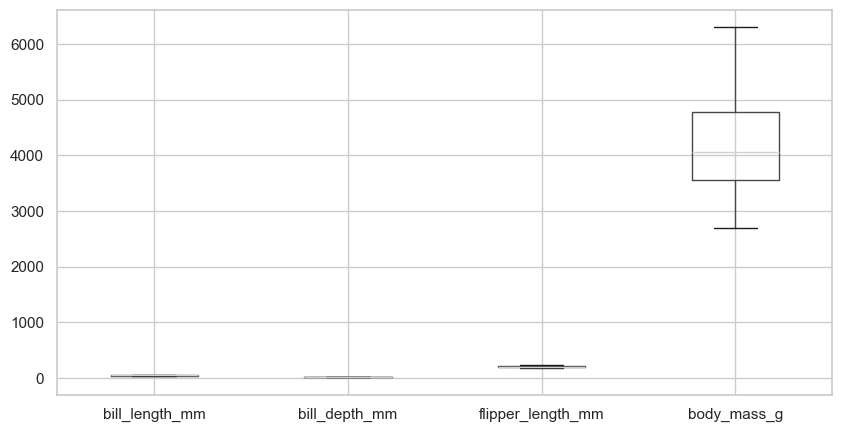

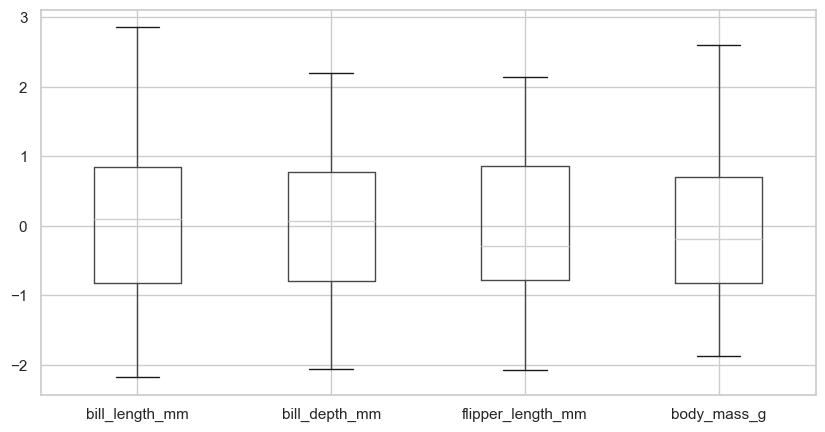

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,3.330000e+02,3.330000e+02,3.330000e+02,3.330000e+02
mean,3.840772e-16,6.401286e-16,2.133762e-16,-1.707010e-16
std,1.001505e+00,1.001505e+00,1.001505e+00,1.001505e+00
min,-2.177987e+00,-2.067291e+00,-2.069852e+00,-1.874435e+00
25%,-8.227879e-01,-7.958519e-01,-7.836512e-01,-8.172292e-01
50%,9.288742e-02,6.872642e-02,-2.834620e-01,-1.953432e-01
75%,8.437412e-01,7.807321e-01,8.598276e-01,7.063915e-01
max,2.858227e+00,2.204743e+00,2.146028e+00,2.603144e+00


In [4]:
# Your code here

X.describe() 

X.boxplot()
plt.show()

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_scaled.boxplot()
plt.show()

X_scaled.describe()

### Exercise 1.4 *** — StandardScaler vs MinMaxScaler

Try scaling with `MinMaxScaler` as well (scales everything to 0-1). Compare:
- How does MinMaxScaler handle outliers differently than StandardScaler?
- When might you prefer one over the other?

*Hint: StandardScaler is sensitive to outliers because it uses mean/std. MinMaxScaler is even more sensitive because a single extreme value stretches the range.*

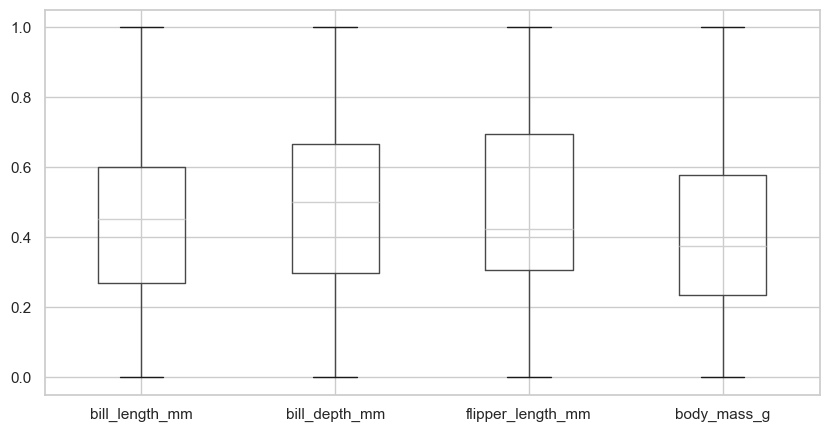

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,333.000000,333.000000,333.000000,333.000000
mean,0.432465,0.483912,0.490966,0.418627
std,0.198861,0.234433,0.237555,0.223671
min,0.000000,0.000000,0.000000,0.000000
25%,0.269091,0.297619,0.305085,0.236111
50%,0.450909,0.500000,0.423729,0.375000
75%,0.600000,0.666667,0.694915,0.576389
max,1.000000,1.000000,1.000000,1.000000


In [5]:
# Your code here
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_scaled.boxplot()
plt.show()

X_scaled.describe()

### Git checkpoint — commit the shared foundation

Before branching, everyone should have the same starting point:

```bash
git add unsupervised_ml_workshop.ipynb
git commit -m "Complete Part 1: data preparation and scaling"
git push origin main
```

Make sure everyone pulls:
```bash
git pull origin main
```

---

---
## Part 2: Clustering Experiments (~45 min)

### Branch out!

Each group member picks **one** algorithm and creates a branch for it:

| Algorithm | Branch name | Key idea |
|-----------|-------------|----------|
| K-Means | `experiment/kmeans` | Partition into fixed K clusters by minimizing within-cluster distance |
| Agglomerative | `experiment/agglomerative` | Build a hierarchy of clusters bottom-up, visualize as dendrogram |
| DBSCAN | `experiment/dbscan` | Group by density, automatically detect noise/outliers |

```bash
git checkout -b experiment/<your-algorithm>
```

From here on, **work on your own branch**. You will all work in the same notebook but on different exercises below. When you are done, you will each commit and push your branch, then open a Pull Request.

---

### 2A: K-Means Clustering

*Work on branch `experiment/kmeans`*

#### Exercise 2A.1 * — Run K-Means

Fit K-Means with an initial guess for `k` (try k=3):

```python
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)
```

1. Add the cluster labels to your dataframe
2. How many points ended up in each cluster?
3. Pick two features and create a scatter plot colored by cluster label

Useful: `sns.scatterplot(hue=...)`, `.value_counts()`

cluster
0    125
1    119
2     89
Name: count, dtype: int64


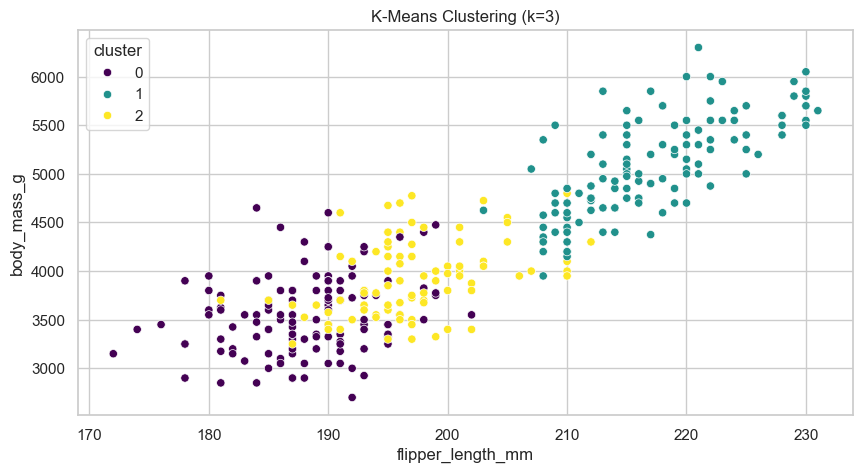

In [10]:
# Your code here

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

df["cluster"] = labels 

print(df["cluster"].value_counts()) 

sns.scatterplot(
    data=df,
    x="flipper_length_mm",
    y="body_mass_g",
    hue="cluster",
    palette="viridis"
)

plt.title("K-Means Clustering (k=3)")
plt.show()

#### Exercise 2A.2 ** — The Elbow Method

How do you choose the right number of clusters? The **elbow method** plots the within-cluster sum of squares (inertia) for different values of K:

1. Run K-Means for k = 2, 3, 4, ..., 10
2. For each k, record `kmeans.inertia_`
3. Plot k vs. inertia — look for the "elbow" where adding more clusters stops helping much

What value of k does the elbow suggest?

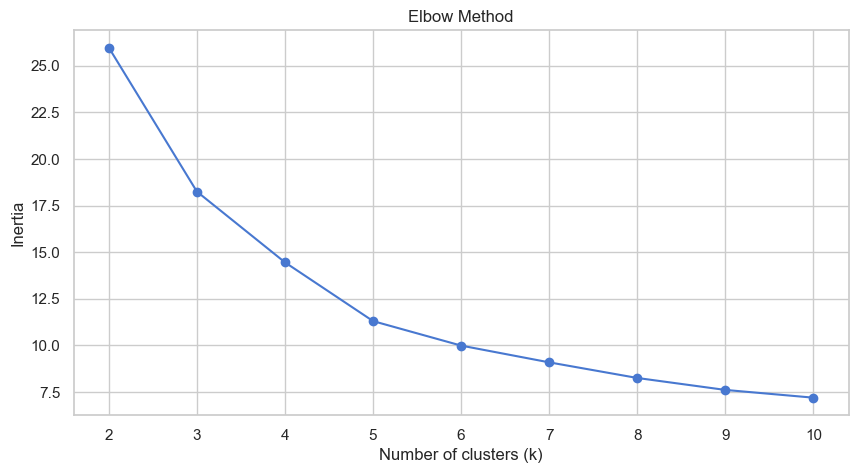

In [12]:
# Your code here

inertia = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(k_values, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

#### Exercise 2A.3 ** — Silhouette Score

The silhouette score measures how similar each point is to its own cluster vs. the nearest neighboring cluster. It ranges from -1 (wrong cluster) to +1 (well-clustered).

1. Calculate the silhouette score for your chosen k: `silhouette_score(X_scaled, labels)`
2. Also calculate it for other values of k — does the best silhouette score agree with the elbow?
3. *Optional:* Create a silhouette plot showing per-sample scores

Silhouette score (k=3): 0.2837784693836971
k=2, silhouette=0.549
k=3, silhouette=0.433
k=4, silhouette=0.379
k=5, silhouette=0.366
k=6, silhouette=0.356
k=7, silhouette=0.327
k=8, silhouette=0.283
k=9, silhouette=0.292
k=10, silhouette=0.284


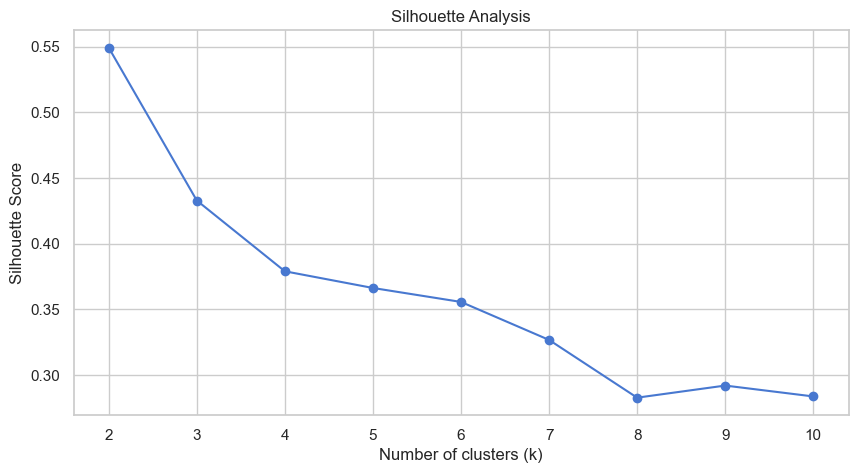

In [15]:
# Your code here

from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, labels)
print("Silhouette score (k=3):", score)

scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)
    print(f"k={k}, silhouette={score:.3f}")

import matplotlib.pyplot as plt

plt.plot(k_values, scores, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()

#### Exercise 2A.4 ** — Interpret the clusters

Clusters are only useful if they *mean something*:

1. Group the **original (unscaled)** data by cluster label and compute the mean of each feature
2. Can you give each cluster a descriptive name? (e.g., "high-income low-spenders")
3. Visualize the cluster centers as a heatmap or bar chart

*Important: interpret using the original scale, not the scaled values — those are harder to reason about.*

Cluster means (original scale):
         bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
cluster                                                               
0             38.340000      18.017600         188.104000  3554.200000
1             47.568067      14.996639         217.235294  5092.436975
2             47.151685      18.866292         197.280899  3940.168539


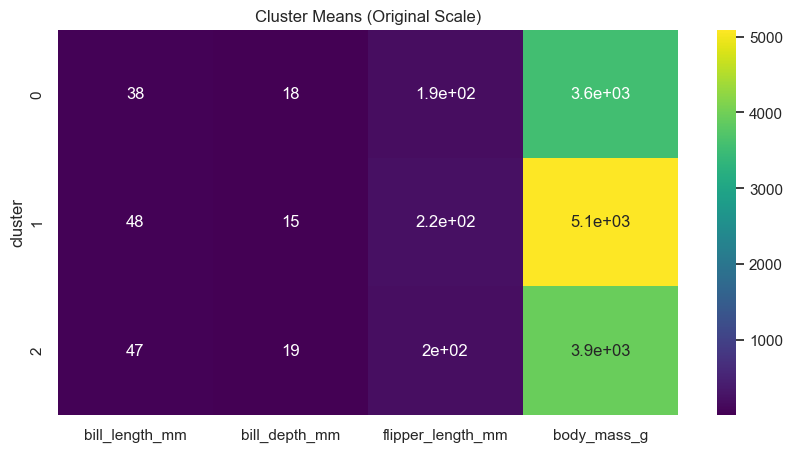

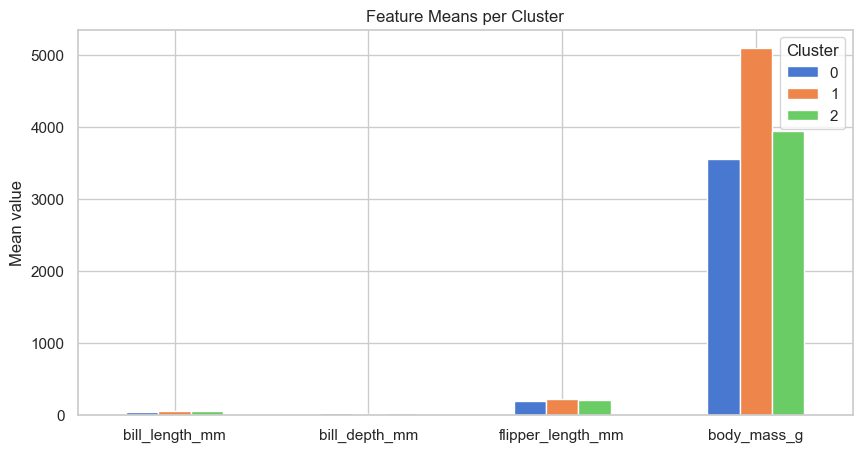

In [18]:
# Your code here

# 1. Gruppa originaldata per cluster och räkna medelvärden
cluster_means = df.groupby("cluster").mean(numeric_only=True)

print("Cluster means (original scale):")
print(cluster_means)

# 2. Visualisering 1: Heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(cluster_means, annot=True, cmap="viridis")
plt.title("Cluster Means (Original Scale)")
plt.show()

# 3. Visualisering 2: Bar plot (lättare att jämföra features)
cluster_means.T.plot(kind="bar", figsize=(10, 5))
plt.title("Feature Means per Cluster")
plt.ylabel("Mean value")
plt.xticks(rotation=0)
plt.legend(title="Cluster")
plt.show()

#### Exercise 2A.5 *** — K-Means limitations

K-Means assumes clusters are spherical and roughly equal-sized. Try to show a case where it struggles:

1. If your data has clusters of very different sizes or non-spherical shapes, visualize where K-Means makes mistakes
2. *Optional:* Generate the `two_moons` toy dataset and show K-Means failing:
   ```python
   from sklearn.datasets import make_moons
   X_moons, y_moons = make_moons(n_samples=300, noise=0.05, random_state=42)
   ```

Document your findings — this will be valuable for the group comparison.

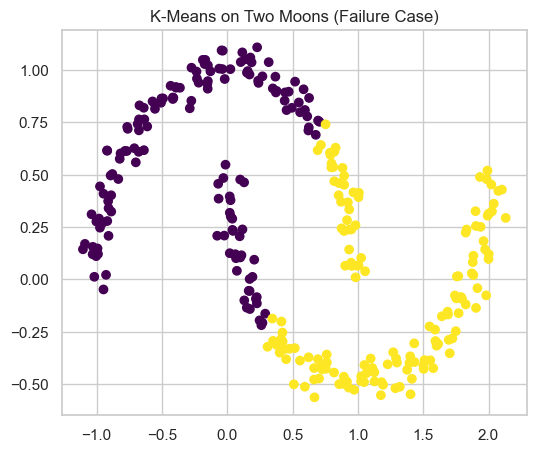

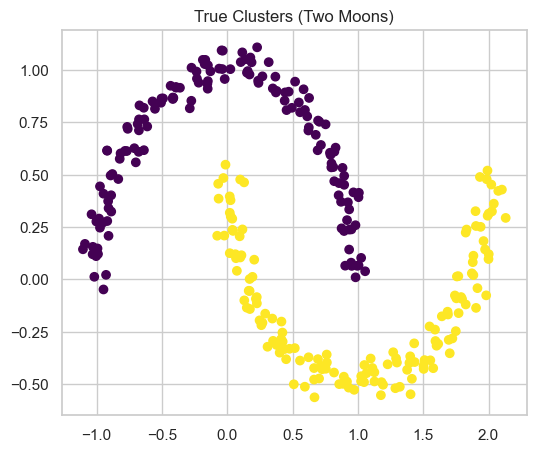

In [21]:
# Your code here

import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans

# Create dataset
X_moons, y_moons = make_moons(n_samples=300, noise=0.05, random_state=42)

# Fit K-Means
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_moons)

# Plot result
plt.figure(figsize=(6,5))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=labels, cmap="viridis")
plt.title("K-Means on Two Moons (Failure Case)")
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap="viridis")
plt.title("True Clusters (Two Moons)")
plt.show()

## K-Means Limitations — Findings

K-Means performs well when clusters are roughly spherical, evenly sized, and linearly separable. However, when these assumptions are violated, the algorithm struggles significantly.

In the **two moons dataset**, the true clusters are non-linear and interleaved in a curved shape. When applying K-Means with k=2, the algorithm incorrectly splits the data using a linear decision boundary instead of following the natural structure of the data.

As a result, points from different moons are assigned to the same cluster, and each true cluster is split across both predicted clusters. This demonstrates that K-Means is not suitable for non-convex cluster shapes or datasets with curved boundaries.

### Key observations:
- K-Means assumes spherical cluster geometry
- It uses Euclidean distance, which enforces linear separation
- It fails on curved / non-linear structures (e.g., two moons)
- Cluster assignments do not match the true labels

### Conclusion:
K-Means is effective for simple, well-separated datasets but breaks down when cluster shapes are complex. Alternative methods such as DBSCAN or hierarchical clustering are better suited for non-linear cluster structures.

---
### 2B: Agglomerative (Hierarchical) Clustering

*Work on branch `experiment/agglomerative`*

#### Exercise 2B.1 * — Build a dendrogram

Before running the clustering, visualize the hierarchy:

```python
Z = linkage(X_scaled, method='ward')
plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='lastp', p=30)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Cluster size')
plt.ylabel('Distance')
plt.show()
```

1. Look at the dendrogram — where would you "cut" it to form clusters?
2. How many clusters does the structure suggest?

*Recall from the lecture: you can cut the dendrogram at different heights to get different numbers of clusters.*

In [ ]:
# Your code here


#### Exercise 2B.2 * — Run Agglomerative Clustering

Now cluster with the number of clusters you chose from the dendrogram:

```python
agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels = agg.fit_predict(X_scaled)
```

1. Add the cluster labels to your dataframe
2. How many points in each cluster?
3. Create a scatter plot colored by cluster label

In [ ]:
# Your code here


#### Exercise 2B.3 ** — Experiment with linkage methods

The linkage method defines how the distance between clusters is measured. Try different methods and compare the dendrograms:

- `ward` — minimizes within-cluster variance (tends to produce equal-sized clusters)
- `complete` — maximum distance between clusters
- `average` — average distance between clusters
- `single` — minimum distance (can produce long, chain-like clusters)

1. Plot dendrograms for at least two different linkage methods side by side
2. How do the resulting cluster structures differ?
3. Which linkage method seems best for your data?

In [ ]:
# Your code here


#### Exercise 2B.4 ** — Silhouette Score & Interpretation

1. Calculate the silhouette score for your clustering
2. Try different numbers of clusters (2-8) and plot k vs. silhouette score
3. Group the **original (unscaled)** data by cluster and compute means — can you name the clusters?

In [ ]:
# Your code here


#### Exercise 2B.5 *** — Pros and cons in practice

Agglomerative clustering doesn't require specifying k in advance (you can read it from the dendrogram), but it is slower on large datasets.

1. If your dataset is large, time the clustering: `%%timeit` or `import time`
2. Compare with K-Means on the same data — which is faster?
3. When would you choose agglomerative over K-Means?

Document your findings for the group comparison.

In [ ]:
# Your code here


---
### 2C: DBSCAN

*Work on branch `experiment/dbscan`*

#### Exercise 2C.1 * — Run DBSCAN

DBSCAN needs two parameters instead of the number of clusters:
- `eps` — the maximum distance between two points to be considered neighbors
- `min_samples` — how many neighbors a point needs to be a core point

Start with default-ish values:

```python
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(X_scaled)
```

1. Add labels to your dataframe. Note: label `-1` means **noise** (outlier)
2. How many clusters were found? How many noise points?
3. Create a scatter plot — color clusters normally, mark noise points distinctly

In [ ]:
# Your code here


#### Exercise 2C.2 ** — Tuning eps with a k-distance plot

Choosing `eps` is the hardest part of DBSCAN. The **k-distance plot** helps:

1. For each point, compute the distance to its k-th nearest neighbor (use k = `min_samples`)
2. Sort these distances and plot them
3. Look for an "elbow" — this suggests a good value for `eps`

```python
from sklearn.neighbors import NearestNeighbors

k = 5
nn = NearestNeighbors(n_neighbors=k)
nn.fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

plt.plot(k_distances)
plt.ylabel(f'{k}-th nearest neighbor distance')
plt.xlabel('Points (sorted)')
plt.title('k-Distance Plot')
plt.show()
```

Re-run DBSCAN with the eps you chose from the plot. Did the results improve?

In [ ]:
# Your code here


#### Exercise 2C.3 ** — Sensitivity to parameters

DBSCAN results can change dramatically with different `eps` and `min_samples`. Explore this:

1. Try at least 3 different combinations of `eps` and `min_samples`
2. For each, record: number of clusters found, number of noise points, silhouette score (excluding noise)
3. Visualize the results side by side

*When calculating silhouette score with DBSCAN, exclude noise points (label == -1), since they are not assigned to any cluster.*

In [ ]:
# Your code here


#### Exercise 2C.4 ** — Interpret the clusters and noise

1. Group the **original (unscaled)** data by cluster label (excluding noise) and compute means
2. Look at the noise points separately — do they share any characteristics? Are they genuine outliers?
3. Can you name the clusters?

In [ ]:
# Your code here


#### Exercise 2C.5 *** — Where DBSCAN shines

DBSCAN can find clusters of arbitrary shape — something K-Means cannot do.

1. Generate the `two_moons` dataset and run DBSCAN on it:
   ```python
   from sklearn.datasets import make_moons
   X_moons, y_moons = make_moons(n_samples=300, noise=0.05, random_state=42)
   ```
2. Compare the DBSCAN result with K-Means (k=2) on the same data
3. Which algorithm recovers the true shape?

Document your findings for the group comparison.

In [ ]:
# Your code here


### Git checkpoint — push your experiment branch

Commit your work and push your branch:

```bash
git add unsupervised_ml_workshop.ipynb
git commit -m "Complete experiment: <your-algorithm>"
git push -u origin experiment/<your-algorithm>
```

---

---
## Part 3: Pull Requests & Comparison (~20 min)

Now comes the collaborative part. Each member has run a different experiment on their own branch — time to compare.

### Step 1 — Open a Pull Request

Each member opens a PR from their experiment branch to `main`:

1. Go to the fork on GitHub
2. Click **"Compare & pull request"** for your branch
3. Title: `Experiment: <Algorithm Name>`
4. In the description, include:
   - Number of clusters found
   - Silhouette score
   - One key strength of this algorithm on your data
   - One limitation you noticed

### Step 2 — Review each other's PRs

Read your groupmates' PRs and leave at least one comment:
- Do their clusters make sense?
- Did they find different groupings than you?
- Any suggestions or questions?

### Step 3 — Merge the PRs

After reviewing, merge all PRs into `main`. If there are merge conflicts in the notebook, resolve them together.

*This mirrors how data science teams work: parallel experiments on branches, comparison through PRs, best approach merged into the main codebase.*

---

---
## Part 4: Synthesis (~15 min)

**Do this together as a group, back on `main`:**

```bash
git checkout main
git pull origin main
```

### Exercise 4.1 * — Comparison table

Fill in this table based on your group's experiments:

| | K-Means | Agglomerative | DBSCAN |
|---|---------|---------------|--------|
| Clusters found | ? | ? | ? |
| Silhouette score | ? | ? | ? |
| Handles noise/outliers? | ? | ? | ? |
| Needs k specified? | ? | ? | ? |
| Cluster shapes | ? | ? | ? |
| Speed | ? | ? | ? |

Which algorithm worked best for your dataset, and why?

*Fill in your comparison here*


### Exercise 4.2 ** — Side-by-side visualization

Create a figure with 3 subplots showing the same scatter plot (same two features) colored by each algorithm's labels. This makes the differences immediately visible.

```python
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Plot each algorithm's clusters on its own subplot
```

In [ ]:
# Your code here


### Exercise 4.3 ** — Do the algorithms agree?

Check how much the algorithms agree on which points belong together:

1. Create a cross-tabulation between two algorithms' labels: `pd.crosstab(labels_kmeans, labels_dbscan)`
2. Where do they agree? Where do they disagree?
3. If you have a ground-truth label (e.g., species for penguins), which algorithm recovers it best?

In [ ]:
# Your code here


### Exercise 4.4 *** — What would you recommend?

Write a short recommendation (5-10 sentences) as if advising a colleague:

1. Which algorithm would you use for this dataset and why?
2. How many clusters do you recommend?
3. What are the clusters and what do they mean in the domain context?
4. What are the limitations of your analysis?
5. What would you try next?

*Write your recommendation here*


### Final commit

```bash
git add unsupervised_ml_workshop.ipynb
git commit -m "Complete synthesis: algorithm comparison"
git push origin main
```

---